In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 1379/1379 [00:00<00:00, 846720.13 examples/s]


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [11]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 1379/1379 [00:00<00:00, 73746.59 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [27]:
import sys
sys.path.insert(0, '../')

In [28]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
num_labels = 1

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [25]:
outputs.keys()

odict_keys(['loss', 'logits', 'hidden_states', 'attentions'])

In [26]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

In [27]:
len(outputs.hidden_states['hidden_states']), outputs.hidden_states['hidden_states'][0].shape

(13, torch.Size([32, 100, 768]))

In [28]:
len(outputs.attentions['attention_head'])

12

In [29]:
outputs.attentions['attention_head'][0].shape

torch.Size([32, 12, 100, 100])

In [30]:
import torch

In [31]:
a = torch.tensor([[[1, 2],
                   [3, 4]],
                  [[5, 6],
                   [7, 8]]])

In [32]:
a.shape

torch.Size([2, 2, 2])

In [33]:
b = torch.flatten(a, start_dim=1)
b, b.shape

(tensor([[1, 2, 3, 4],
         [5, 6, 7, 8]]),
 torch.Size([2, 4]))

In [34]:
c = torch.flatten(b, start_dim=1)
c, c.shape

(tensor([[1, 2, 3, 4],
         [5, 6, 7, 8]]),
 torch.Size([2, 4]))

In [35]:
outputs.attentions['attention_output'][0].shape

torch.Size([32, 100, 768])

### Loading Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device, regression=True)

({'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651},
 0.4520208261748578)

# 5. Similarity Analysis

In [32]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [33]:
from CKA import SentenceCKARedundancy

headsCka_eval = SentenceCKARedundancy(device)

In [34]:
def adjacent_similarity_stats(
    similarity_scores, 
    thresold = 0.80,
    disp_sim_score=True, 
    disp_group_count=True
):
    adj_similarities = []
    for i in range(1, len(similarity_scores)):
        adj_similarities.append(similarity_scores[i-1][i])

    if disp_sim_score:
        print("Similarity Scores:", adj_similarities)

    high_pair_count = 0
    for pair in adj_similarities:
        if pair > thresold:
            high_pair_count += 1
    
    if disp_group_count:
        print("Number of High Similar Pairs:", high_pair_count)

    return adj_similarities, high_pair_count

### Using Training Data on CLS Token only

In [35]:
reps_similarity, atts_similarity, mha_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
mha_stats = cka_eval.similarity_stats(mha_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  MHA Similarity Stats:")
print(f"    Average: {mha_stats['average']:.6f}")
print(f"    Highest: {mha_stats['max']:.6f}")
print(f"    Lowest:  {mha_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:31<00:00,  3.68it/s]

  Reps Similarity Stats:
    Average: 0.924090
    Highest: 0.993473
    Lowest:  0.550061

  Atts Similarity Stats:
    Average: 0.934734
    Highest: 0.992286
    Lowest:  0.782494
  MHA Similarity Stats:
    Average: 0.927925
    Highest: 0.992308
    Lowest:  0.648581
  Sublayer Similarity Stats:
    Average: 0.953758
    Highest: 0.995058
    Lowest:  0.627364


In [36]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

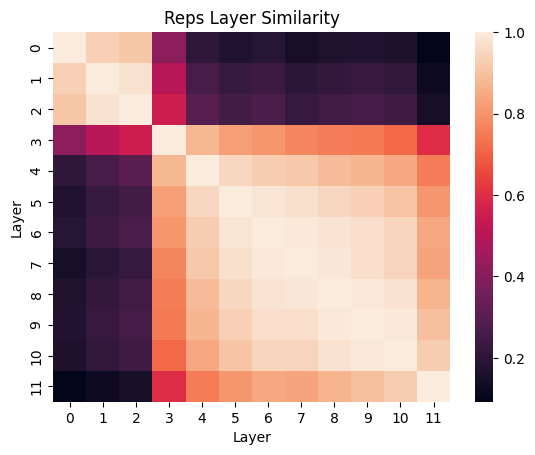

In [37]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [38]:
_,_ = adjacent_similarity_stats(reps_similarity)

Similarity Scores: [0.9345629, 0.9778014, 0.55006135, 0.87699884, 0.9510381, 0.9834207, 0.9904151, 0.98720735, 0.99347275, 0.99146384, 0.9285449]
Number of High Similar Pairs: 10


In [39]:
_,_ = adjacent_similarity_stats(reps_similarity, thresold=0.85)

Similarity Scores: [0.9345629, 0.9778014, 0.55006135, 0.87699884, 0.9510381, 0.9834207, 0.9904151, 0.98720735, 0.99347275, 0.99146384, 0.9285449]
Number of High Similar Pairs: 10


In [40]:
_,_ = adjacent_similarity_stats(reps_similarity, thresold=0.9)

Similarity Scores: [0.9345629, 0.9778014, 0.55006135, 0.87699884, 0.9510381, 0.9834207, 0.9904151, 0.98720735, 0.99347275, 0.99146384, 0.9285449]
Number of High Similar Pairs: 9


Text(50.722222222222214, 0.5, 'Layer')

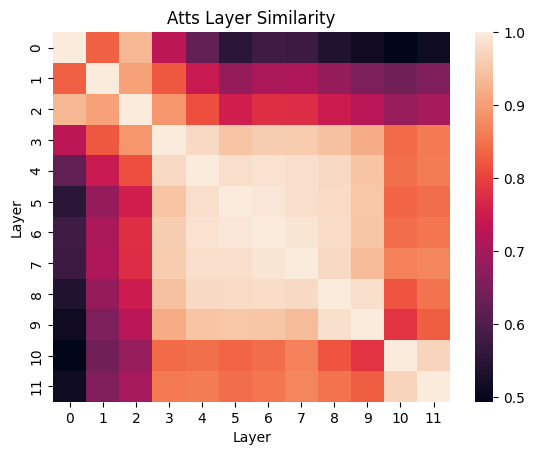

In [41]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [42]:
_,_ = adjacent_similarity_stats(atts_similarity)

Similarity Scores: [0.83090407, 0.90371484, 0.8910227, 0.9755063, 0.9829231, 0.9922863, 0.99148506, 0.9760832, 0.98603356, 0.7824944, 0.96962345]
Number of High Similar Pairs: 10


In [43]:
_,_ = adjacent_similarity_stats(atts_similarity, thresold=0.85)

Similarity Scores: [0.83090407, 0.90371484, 0.8910227, 0.9755063, 0.9829231, 0.9922863, 0.99148506, 0.9760832, 0.98603356, 0.7824944, 0.96962345]
Number of High Similar Pairs: 9


In [44]:
_,_ = adjacent_similarity_stats(atts_similarity, thresold=0.9)

Similarity Scores: [0.83090407, 0.90371484, 0.8910227, 0.9755063, 0.9829231, 0.9922863, 0.99148506, 0.9760832, 0.98603356, 0.7824944, 0.96962345]
Number of High Similar Pairs: 8


Text(50.722222222222214, 0.5, 'Layer')

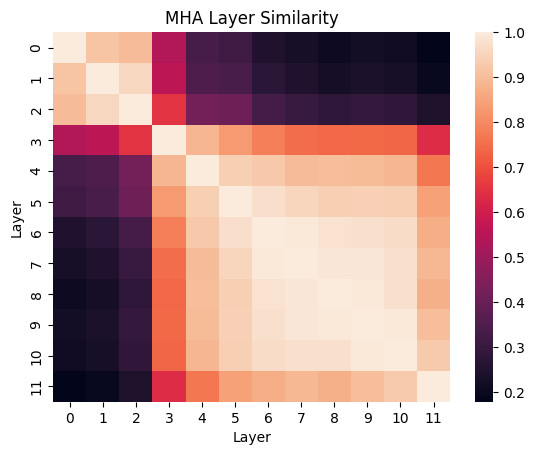

In [45]:
title = "MHA Layer Similarity"
plt.title(title)
sn.heatmap(data = mha_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [46]:
_,_ = adjacent_similarity_stats(mha_similarity)

Similarity Scores: [0.9164039, 0.9563342, 0.6485814, 0.8849233, 0.9389429, 0.97184056, 0.99047434, 0.98946303, 0.992308, 0.9906442, 0.9272605]
Number of High Similar Pairs: 10


In [47]:
_,_ = adjacent_similarity_stats(mha_similarity, thresold=0.85)

Similarity Scores: [0.9164039, 0.9563342, 0.6485814, 0.8849233, 0.9389429, 0.97184056, 0.99047434, 0.98946303, 0.992308, 0.9906442, 0.9272605]
Number of High Similar Pairs: 10


In [48]:
_,_ = adjacent_similarity_stats(mha_similarity, thresold=0.9)

Similarity Scores: [0.9164039, 0.9563342, 0.6485814, 0.8849233, 0.9389429, 0.97184056, 0.99047434, 0.98946303, 0.992308, 0.9906442, 0.9272605]
Number of High Similar Pairs: 9


Text(50.722222222222214, 0.5, 'Layer')

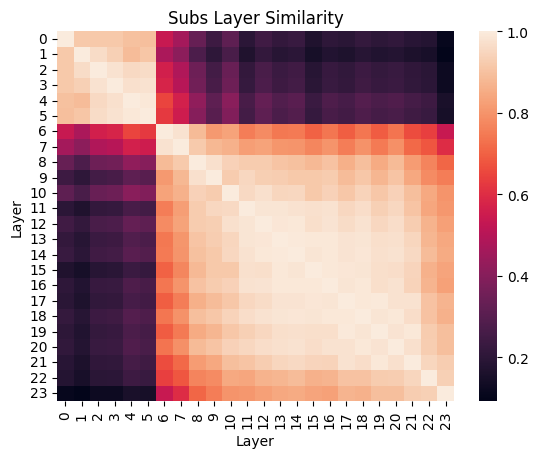

In [49]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [50]:
_,_ = adjacent_similarity_stats(sub_similarity)

Similarity Scores: [0.91495866, 0.9620689, 0.9759058, 0.9729286, 0.9927781, 0.62736434, 0.9781021, 0.91906637, 0.9742467, 0.9230543, 0.9550541, 0.98480994, 0.9886346, 0.99505794, 0.9834829, 0.9912209, 0.9836966, 0.9894116, 0.98556054, 0.9820069, 0.9743261, 0.94706976, 0.93562883]
Number of High Similar Pairs: 22


In [51]:
_,_ = adjacent_similarity_stats(sub_similarity, thresold=0.85)

Similarity Scores: [0.91495866, 0.9620689, 0.9759058, 0.9729286, 0.9927781, 0.62736434, 0.9781021, 0.91906637, 0.9742467, 0.9230543, 0.9550541, 0.98480994, 0.9886346, 0.99505794, 0.9834829, 0.9912209, 0.9836966, 0.9894116, 0.98556054, 0.9820069, 0.9743261, 0.94706976, 0.93562883]
Number of High Similar Pairs: 22


In [52]:
_,_ = adjacent_similarity_stats(sub_similarity, thresold=0.9)

Similarity Scores: [0.91495866, 0.9620689, 0.9759058, 0.9729286, 0.9927781, 0.62736434, 0.9781021, 0.91906637, 0.9742467, 0.9230543, 0.9550541, 0.98480994, 0.9886346, 0.99505794, 0.9834829, 0.9912209, 0.9836966, 0.9894116, 0.98556054, 0.9820069, 0.9743261, 0.94706976, 0.93562883]
Number of High Similar Pairs: 22


### Using Val Data on CLS Token only

In [53]:
val_reps_similarity, val_atts_similarity, val_mha_similarity, val_sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    val_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
val_reps_stats = cka_eval.similarity_stats(val_reps_similarity)
val_atts_stats = cka_eval.similarity_stats(val_atts_similarity)
val_mha_stats  = cka_eval.similarity_stats(val_mha_similarity)
val_subs_stats = cka_eval.similarity_stats(val_sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {val_reps_stats['average']:.6f}")
print(f"    Highest: {val_reps_stats['max']:.6f}")
print(f"    Lowest:  {val_reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {val_atts_stats['average']:.6f}")
print(f"    Highest: {val_atts_stats['max']:.6f}")
print(f"    Lowest:  {val_atts_stats['min']:.6f}")

print("  MHA Similarity Stats:")
print(f"    Average: {val_mha_stats['average']:.6f}")
print(f"    Highest: {val_mha_stats['max']:.6f}")
print(f"    Lowest:  {val_mha_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {val_subs_stats['average']:.6f}")
print(f"    Highest: {val_subs_stats['max']:.6f}")
print(f"    Lowest:  {val_subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 47/47 [00:12<00:00,  3.91it/s]

  Reps Similarity Stats:
    Average: 0.908746
    Highest: 0.992311
    Lowest:  0.568312

  Atts Similarity Stats:
    Average: 0.947004
    Highest: 0.995187
    Lowest:  0.781282
  MHA Similarity Stats:
    Average: 0.919664
    Highest: 0.991082
    Lowest:  0.659944
  Sublayer Similarity Stats:
    Average: 0.947109
    Highest: 0.994445
    Lowest:  0.646118


Text(50.722222222222214, 0.5, 'Layer')

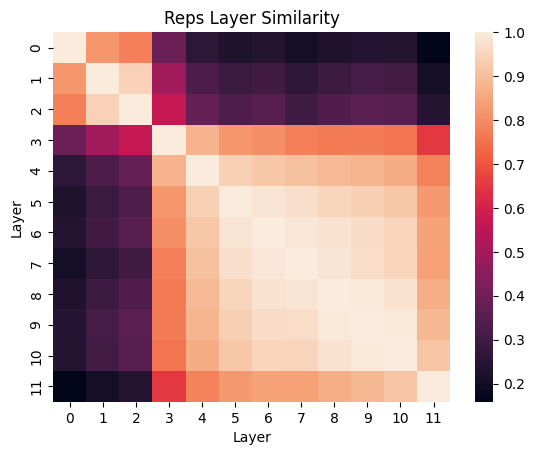

In [54]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = val_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [55]:
_,_ = adjacent_similarity_stats(val_reps_similarity)

Similarity Scores: [0.81813633, 0.94325304, 0.56831235, 0.8761137, 0.9384521, 0.98216295, 0.9879108, 0.98630494, 0.99162424, 0.99231136, 0.91162395]
Number of High Similar Pairs: 10


In [56]:
_,_ = adjacent_similarity_stats(val_reps_similarity, thresold=0.85)

Similarity Scores: [0.81813633, 0.94325304, 0.56831235, 0.8761137, 0.9384521, 0.98216295, 0.9879108, 0.98630494, 0.99162424, 0.99231136, 0.91162395]
Number of High Similar Pairs: 9


In [57]:
_,_ = adjacent_similarity_stats(val_reps_similarity, thresold=0.9)

Similarity Scores: [0.81813633, 0.94325304, 0.56831235, 0.8761137, 0.9384521, 0.98216295, 0.9879108, 0.98630494, 0.99162424, 0.99231136, 0.91162395]
Number of High Similar Pairs: 8


Text(50.722222222222214, 0.5, 'Layer')

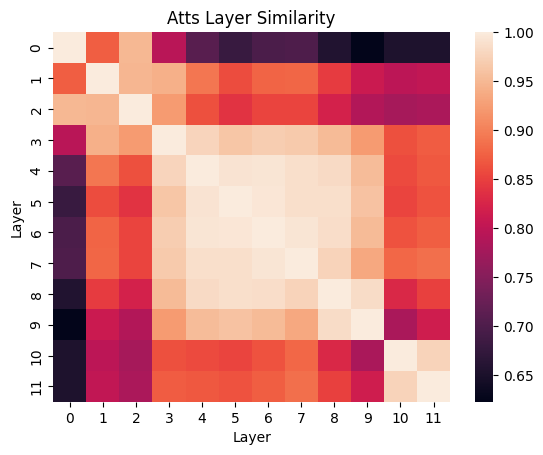

In [58]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = val_atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [59]:
_,_ = adjacent_similarity_stats(val_atts_similarity)

Similarity Scores: [0.8725802, 0.9479796, 0.92202944, 0.97752655, 0.99160606, 0.99518657, 0.993353, 0.97594076, 0.9843724, 0.7812823, 0.9751841]
Number of High Similar Pairs: 10


In [60]:
_,_ = adjacent_similarity_stats(val_atts_similarity, thresold=0.85)

Similarity Scores: [0.8725802, 0.9479796, 0.92202944, 0.97752655, 0.99160606, 0.99518657, 0.993353, 0.97594076, 0.9843724, 0.7812823, 0.9751841]
Number of High Similar Pairs: 10


In [61]:
_,_ = adjacent_similarity_stats(val_atts_similarity, thresold=0.9)

Similarity Scores: [0.8725802, 0.9479796, 0.92202944, 0.97752655, 0.99160606, 0.99518657, 0.993353, 0.97594076, 0.9843724, 0.7812823, 0.9751841]
Number of High Similar Pairs: 9


Text(50.722222222222214, 0.5, 'Layer')

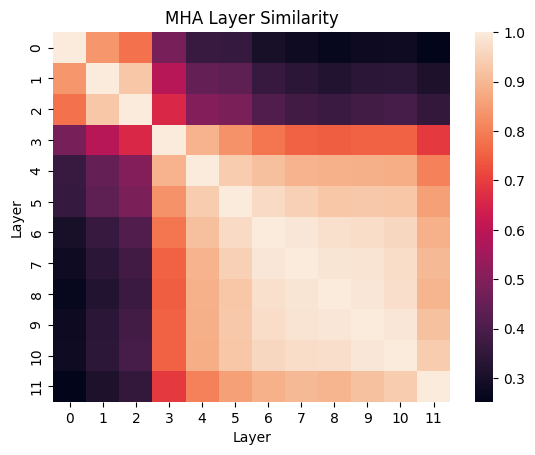

In [62]:
title = "MHA Layer Similarity"
plt.title(title)
sn.heatmap(data = val_mha_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [63]:
_,_ = adjacent_similarity_stats(val_mha_similarity)

Similarity Scores: [0.83800465, 0.92886883, 0.65994394, 0.8908434, 0.9357787, 0.96668154, 0.9898982, 0.9867937, 0.99108243, 0.9908186, 0.9375862]
Number of High Similar Pairs: 10


In [64]:
_,_ = adjacent_similarity_stats(val_mha_similarity, thresold=0.85)

Similarity Scores: [0.83800465, 0.92886883, 0.65994394, 0.8908434, 0.9357787, 0.96668154, 0.9898982, 0.9867937, 0.99108243, 0.9908186, 0.9375862]
Number of High Similar Pairs: 9


In [65]:
_,_ = adjacent_similarity_stats(val_mha_similarity, thresold=0.9)

Similarity Scores: [0.83800465, 0.92886883, 0.65994394, 0.8908434, 0.9357787, 0.96668154, 0.9898982, 0.9867937, 0.99108243, 0.9908186, 0.9375862]
Number of High Similar Pairs: 8


Text(50.722222222222214, 0.5, 'Layer')

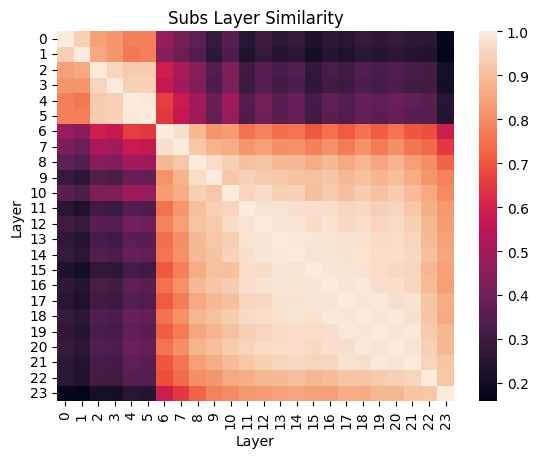

In [66]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = val_sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [67]:
_,_ = adjacent_similarity_stats(val_sub_similarity)

Similarity Scores: [0.93945247, 0.8532124, 0.95171845, 0.9396265, 0.99188834, 0.6461184, 0.97587585, 0.9196684, 0.9693178, 0.91967386, 0.94913566, 0.98276097, 0.9876644, 0.99444485, 0.98120475, 0.98761904, 0.98445714, 0.9886601, 0.987075, 0.98405844, 0.9814397, 0.9475973, 0.92082995]
Number of High Similar Pairs: 22


In [68]:
_,_ = adjacent_similarity_stats(val_sub_similarity, thresold=0.85)

Similarity Scores: [0.93945247, 0.8532124, 0.95171845, 0.9396265, 0.99188834, 0.6461184, 0.97587585, 0.9196684, 0.9693178, 0.91967386, 0.94913566, 0.98276097, 0.9876644, 0.99444485, 0.98120475, 0.98761904, 0.98445714, 0.9886601, 0.987075, 0.98405844, 0.9814397, 0.9475973, 0.92082995]
Number of High Similar Pairs: 22


In [69]:
_,_ = adjacent_similarity_stats(val_sub_similarity, thresold=0.9)

Similarity Scores: [0.93945247, 0.8532124, 0.95171845, 0.9396265, 0.99188834, 0.6461184, 0.97587585, 0.9196684, 0.9693178, 0.91967386, 0.94913566, 0.98276097, 0.9876644, 0.99444485, 0.98120475, 0.98761904, 0.98445714, 0.9886601, 0.987075, 0.98405844, 0.9814397, 0.9475973, 0.92082995]
Number of High Similar Pairs: 21


### Using Training Data using Whole Sequence

In [44]:
reps_similarity, atts_similarity, mha_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=False, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
mha_stats = cka_eval.similarity_stats(mha_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  MHA Similarity Stats:")
print(f"    Average: {mha_stats['average']:.6f}")
print(f"    Highest: {mha_stats['max']:.6f}")
print(f"    Lowest:  {mha_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:41<00:00,  2.80it/s]

  Reps Similarity Stats:
    Average: 0.989591
    Highest: 0.999240
    Lowest:  0.967765

  Atts Similarity Stats:
    Average: 0.944147
    Highest: 0.991294
    Lowest:  0.762895
  MHA Similarity Stats:
    Average: 0.983106
    Highest: 0.998300
    Lowest:  0.953689
  Sublayer Similarity Stats:
    Average: 0.970021
    Highest: 0.987302
    Lowest:  0.958911


In [41]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=False, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:36<00:00,  3.15it/s]

  Reps Similarity Stats:
    Average: 0.989591
    Highest: 0.999240
    Lowest:  0.967765

  Atts Similarity Stats:
    Average: 0.944147
    Highest: 0.991294
    Lowest:  0.762895
  Sublayer Similarity Stats:
    Average: 0.810862
    Highest: 0.962792
    Lowest:  0.402067


Text(50.722222222222214, 0.5, 'Layer')

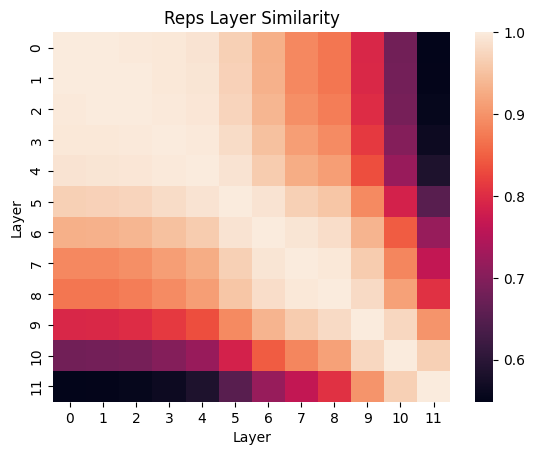

In [45]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

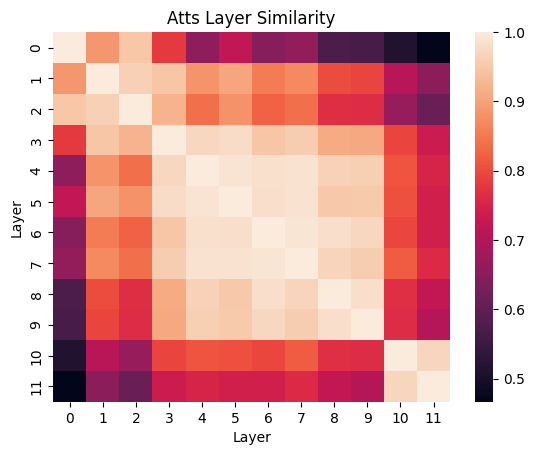

In [46]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

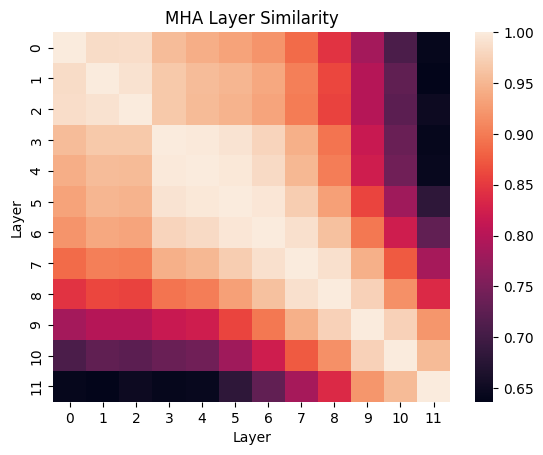

In [47]:
title = "MHA Layer Similarity"
plt.title(title)
sn.heatmap(data = mha_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

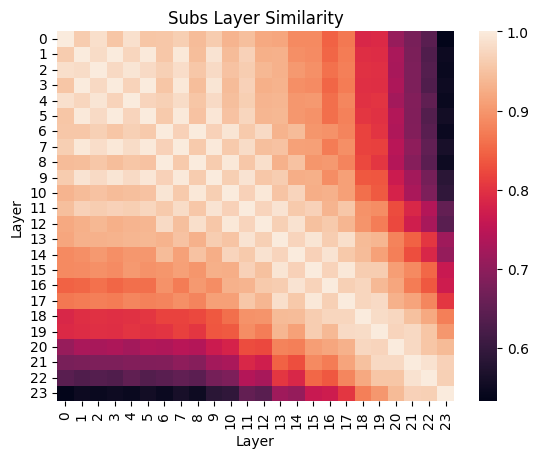

In [48]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### Using Val Data using Whole Sequence

In [49]:
val_reps_similarity, val_atts_similarity, val_mha_similarity, val_sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    val_dataloader, 
    device, 
    only_cls_token=False, 
    max_iter=115
)
val_reps_stats = cka_eval.similarity_stats(val_reps_similarity)
val_atts_stats = cka_eval.similarity_stats(val_atts_similarity)
val_mha_stats  = cka_eval.similarity_stats(val_mha_similarity)
val_subs_stats = cka_eval.similarity_stats(val_sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {val_reps_stats['average']:.6f}")
print(f"    Highest: {val_reps_stats['max']:.6f}")
print(f"    Lowest:  {val_reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {val_atts_stats['average']:.6f}")
print(f"    Highest: {val_atts_stats['max']:.6f}")
print(f"    Lowest:  {val_atts_stats['min']:.6f}")

print("  MHA Similarity Stats:")
print(f"    Average: {val_mha_stats['average']:.6f}")
print(f"    Highest: {val_mha_stats['max']:.6f}")
print(f"    Lowest:  {val_mha_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {val_subs_stats['average']:.6f}")
print(f"    Highest: {val_subs_stats['max']:.6f}")
print(f"    Lowest:  {val_subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 13/13 [00:04<00:00,  2.83it/s]

  Reps Similarity Stats:
    Average: 0.991503
    Highest: 0.999282
    Lowest:  0.970845

  Atts Similarity Stats:
    Average: 0.946210
    Highest: 0.991978
    Lowest:  0.770506
  MHA Similarity Stats:
    Average: 0.983591
    Highest: 0.998318
    Lowest:  0.944361
  Sublayer Similarity Stats:
    Average: 0.968635
    Highest: 0.984541
    Lowest:  0.956600


Text(50.722222222222214, 0.5, 'Layer')

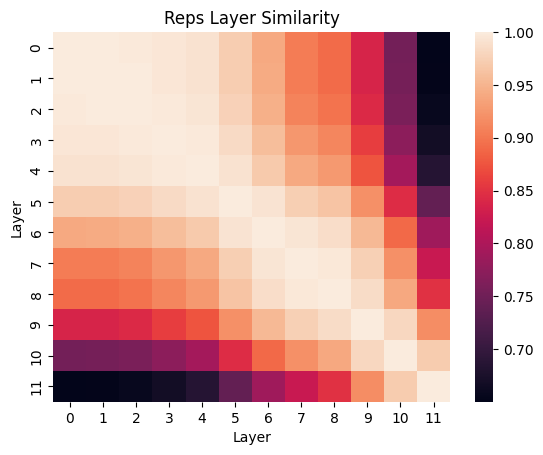

In [50]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = val_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

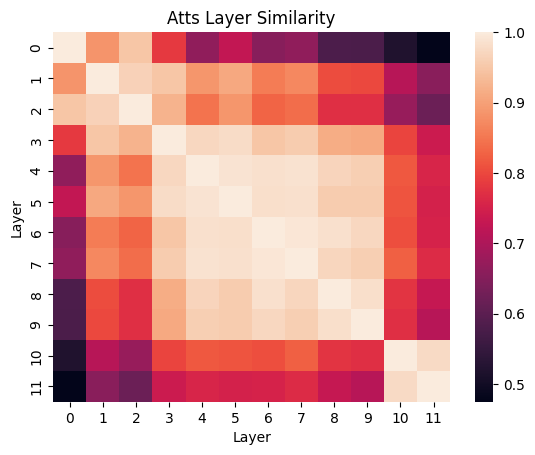

In [51]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = val_atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

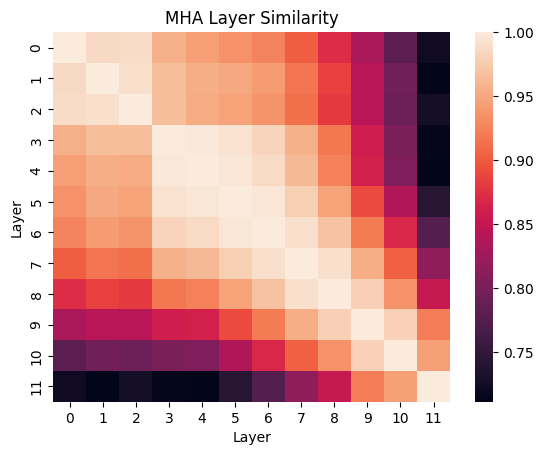

In [52]:
title = "MHA Layer Similarity"
plt.title(title)
sn.heatmap(data = val_mha_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

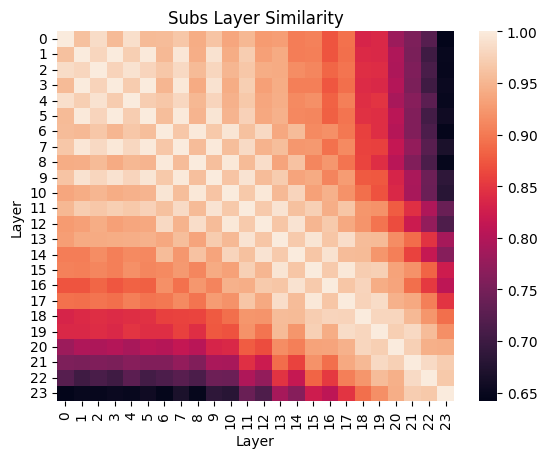

In [53]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = val_sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### Using Training Data for Heads Redundancy

In [ ]:
headsCka_eval

In [47]:
outputs.attentions['attention_head'][0].shape

torch.Size([32, 12, 100, 100])

In [46]:
outputs.attentions['attention_head'][11].shape

torch.Size([32, 12, 100, 100])

In [38]:
from CKA import CudaCKA

In [35]:
from tqdm import tqdm

In [54]:
class TestHeadRedundancyEval:
    def __init__(self, device):
        self.cuda_cka = CudaCKA(device)
 
    def collect_selected_layer_head_matrices(self, atts, layer_indices):
        """
        atts: list of length L, each (batch, heads, seq_q, seq_k)
        layer_indices: which layers to include (e.g. [3], [0,1,2], or
                       None for all layers)
 
        Returns:
            matrices: list of (batch, seq_q, seq_k) tensors, UNFLATTENED.
                      Sentence-level CKA needs the (n, n) shape intact --
                      do not flatten these.
            labels: list of (layer_idx, head_idx) tuples, same order/length
                    as matrices. Required to interpret rows/cols of the
                    returned similarity matrix once more than one layer
                    is involved.
        """
        if layer_indices is None:
            layer_indices = [i for i in range(len(atts))]  # fixed: missing ')'
 
        matrices = []
        labels = []
        for layer_idx in layer_indices:
            layer_att = atts[layer_idx]  # (batch, heads, seq_q, seq_k)
            heads = layer_att.shape[1]
            for h in range(heads):
                matrices.append(layer_att[:, h, :, :])
                labels.append((layer_idx, h))
        return matrices, labels
 
    def _accumulate_batch(self, matrices, attention_mask, scores_accum):
        """
        Adds this batch's per-sentence CKA sums into scores_accum (in place)
        and returns how many valid sentences (n_valid >= 2) contributed.
 
        Diagonal entries are CKA(head_i, head_i) for each sentence, which
        is always exactly 1.0 -- so after normalizing by n_valid_sentences
        the diagonal stays exactly 1.0, guaranteed to be the max of every
        row/column. No special-casing needed for "same head = highest
        similarity"; it falls out of CKA's own definition as long as every
        (i, i) pair is computed the same way as every (i, j) pair below.
        """
        M = len(matrices)
        batch = matrices[0].shape[0]
        n_valid_sentences = 0
 
        with torch.no_grad():
            for b in range(batch):
                # Padding-side agnostic: works regardless of left/right padding.
                valid_idx = attention_mask[b].bool()
                n_valid = int(valid_idx.sum().item())
 
                # Guard against degenerate very-short sentences where
                # linear_CKA's variance terms can be ~0 -> NaN.
                if n_valid < 2:
                    continue
                n_valid_sentences += 1
 
                for i in range(M):
                    Ai = matrices[i][b][valid_idx][:, valid_idx]  # (n_valid, n_valid)
                    for j in range(i, M):
                        Bj = matrices[j][b][valid_idx][:, valid_idx]
                        val = self.cuda_cka.linear_CKA(Ai, Bj).detach()
                        scores_accum[i, j] += val
                        if i != j:
                            scores_accum[j, i] += val
                        # i == j case (diagonal): added once, correctly,
                        # via the scores_accum[i, j] += val line above.
 
        return n_valid_sentences
 
    def att_head_redundancy_estimate(self, model, dataloader, device,
                                      max_iter=float("Inf"), layer_indices=None,
                                      attention_mask_key="attention_mask"):
        """
        Runs sentence-level CKA head-redundancy estimation over an entire
        dataloader. Diagonal of the returned matrix is guaranteed to be
        1.0 (a head is always maximally similar to itself), so every
        row/column's max similarity is its own diagonal entry.
 
        Returns:
            scores: (M, M) numpy array, M = len(layer_indices or all)*heads
            labels: list of (layer_idx, head_idx), same order as rows/cols
        """
        model.set_use_module_grafting(False)
        model.set_use_scc_status(False)
 
        n_batch = len(dataloader)
        n_steps = min(n_batch, max_iter) if max_iter != float("Inf") else n_batch
        progress_bar = tqdm(range(n_steps), desc="CKA Sublayer Evaluation")
 
        model.eval()
 
        scores = None
        labels = None
        total_valid_sentences = 0
 
        for step, batch in enumerate(dataloader):
            if step == max_iter:
                break
 
            batch = {k: v.to(device) for k, v in batch.items()}
            attention_mask = batch[attention_mask_key]
 
            with torch.no_grad():
                output = model(**batch)
 
            atts = output.attentions["attention_head"]  # list of (batch, heads, seq_q, seq_k)
 
            matrices, labels = self.collect_selected_layer_head_matrices(atts, layer_indices)
 
            if scores is None:
                M = len(matrices)
                scores = torch.zeros(M, M, device=matrices[0].device)
 
            n_valid = self._accumulate_batch(matrices, attention_mask, scores)
            total_valid_sentences += n_valid
 
            progress_bar.update(1)
 
        if total_valid_sentences == 0:
            scores.fill_(float("nan"))
        else:
            scores = scores / total_valid_sentences
 
        # Sanity: diagonal should be (numerically) 1.0 -- confirms the
        # "same head = highest similarity" property holds by construction.
        return scores.cpu().numpy(), labels

In [55]:
test = TestHeadRedundancyEval(device)

In [57]:
scores, labels = test.att_head_redundancy_estimate(model, train_dataloader, device, layer_indices=[10, 11], max_iter=5)

CKA Sublayer Evaluation: 100%|██████████| 5/5 [00:13<00:00,  2.63s/it]


In [43]:
for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    attention_mask = batch['attention_mask']
    with torch.no_grad():
        output = model(**batch)
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 77]),
 'token_type_ids': torch.Size([32, 77]),
 'attention_mask': torch.Size([32, 77])}

In [44]:
len(outputs.attentions['attention_head'])

12

In [45]:
outputs.attentions['attention_head'][0].shape

torch.Size([32, 12, 100, 100])

In [47]:
matrices, labels = test.collect_selected_layer_head_matrices(outputs.attentions['attention_head'], [0, 1])

In [48]:
labels

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11)]

In [50]:
len(matrices)

24

In [52]:
matrices[0].shape

torch.Size([32, 100, 100])

In [58]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Heads')

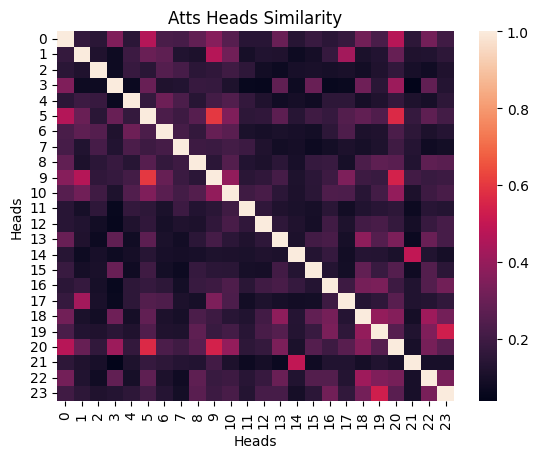

In [59]:
title = "Atts Heads Similarity"
plt.title(title)
sn.heatmap(data = scores)
plt.xlabel("Heads")
plt.ylabel("Heads")